# Image Annotation

Below are some common annotations to images:
* Draw lines
* Draw circles
* Draw rectangles
* Add text

# Draw a line

```python
cv2.line(img, pt1, pt2, color, thickness, lineType, shift)
```

* `cv2.LINE_AA` stands for Anti aliased

# Draw a circle

```python
cv2.circle(img, center, radius, color, thickness, lineType, shift)
```

* when thickness is negative value, it fills the circle

# Draw rectangle

# Adding text

```python
cv2.putText(img, text, org, fontFace, fontScale, color, thickness, lineType, bottomleftorigin)
```

org = bottom left corner of the text string in that image

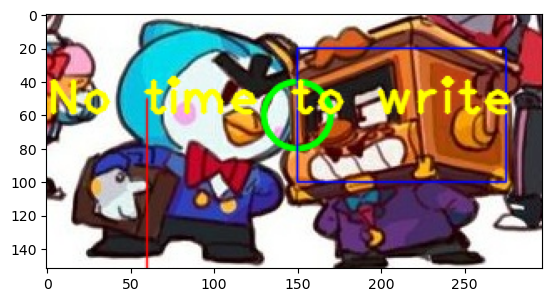

In [188]:
image_line = image.copy()
#(x,y) point notation
cv2.line(image_line, (60,50), (60, 200), (0, 0, 255), lineType=cv2.LINE_AA)
cv2.circle(image_line, (150, 60), 20, (0, 255, 0), thickness=2, lineType=cv2.LINE_AA)

# syntax same as line
# pt1 = top left coordinate
# pt2 = bottom right coordinate
cv2.rectangle(image_line, (150,20), (275,100), (255, 0, 0), lineType=cv2.LINE_AA)

text = "No time to write long texts"
fontScale = 2
fontFace = cv2.FONT_HERSHEY_PLAIN
fontColor = (0,255,255)
fontThickness = 2
cv2.putText(image_line, text, (0,60), fontFace, fontScale, fontColor, fontThickness, cv2.LINE_AA)
plt.imshow(image_line[:,:,::-1])

* `cv2.LINE_16` is not supported by **cv2.line**

# Accessing the camera

```python
import cv2
import sys

s = 0  # camera device index number
if len(sys.argv) > 1:  # check some other index number is provided via commandline
    s = sys.argv[1]

source = cv2.VideoCapture(s)

win_name = 'Camera Preview'
cv2.namedWindow(win_name, cv2.WINDOW_NORMAL)

while cv2.waitKey(1) != 27: # check if Escape key (27) is pressed or not
    has_frame, frame = source.read()
    if not has_frame:
        break
    cv2.imshow(win_name, frame)

source.release()
cv2.destroyWindow(win_name)
```

# Writing a video

In [194]:
source = "bvs.mp4"
cap = cv2.VideoCapture(source)
if cap.isOpened() == False:
    print("Error opening video stream or file")

In [196]:
ret, frame = cap.read()

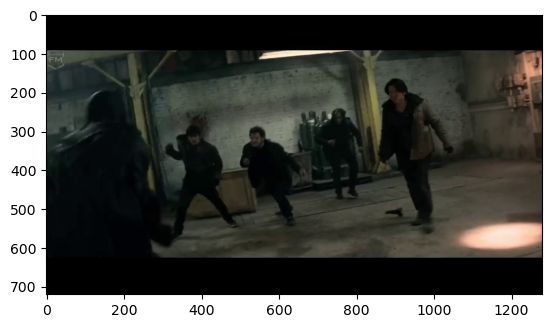

In [198]:
plt.imshow(frame[...,::-1])

In [3]:
from IPython.display import HTML
HTML("""
<video width=512 controls>
  <source src="bvs.mp4" type="video/mp4">
</video>
""")

In [204]:
frame_w = int(cap.get(3))
frame_h = int(cap.get(4))

out_avi = cv2.VideoWriter("bvs.avi", cv2.VideoWriter_fourcc("M", "J", "P", "G"), 10, (frame_w, frame_h))

In [206]:
try:
    while cap.isOpened():
        ret, frame = cap.read()
        if ret:
            out_avi.write(frame)
        else:
            break
except Exception as e:
    print(e)

finally:
    cap.release()
    out_avi.release()

# Image Alignment

* also known as image registeration
* Applications:
  * Used to create panaroma
  * used in medical field to align scans to detect minor changes
  * constructing HDR image from multiple images taken at different exposure

* Translation:
  * Shifting of the pixel coordinates from one location to another
* Euclidean:
  * Rotation
* Affine:
  * Shrear and scale changes (parallels remain parallels)
* Homograph:
  * projection (arbitary quadrilateral)

![alt text](https://learnopencv.com/wp-content/uploads/2023/03/opencv_bootcamp_08_motion-models.jpg "Motion Models")

How to align images:
* We have to identify atleast 4 points that correspond to the same physical location
* 4 is min req. In practice we need more
* By that way we can compute the homograph between two images
* Those 4 points are called corresponding points

!["Homography Example"](https://learnopencv.com/wp-content/uploads/2023/03/opencv_bootcamp_08_homography-example.jpg)

In [218]:
form = cv2.imread("form.jpg", cv2.IMREAD_COLOR)
form = cv2.cvtColor(form, cv2.COLOR_BGR2RGB)
scanned_form = cv2.imread("scanned-form.jpg", cv2.IMREAD_COLOR)
scanned_form = cv2.cvtColor(scanned_form, cv2.COLOR_BGR2RGB)

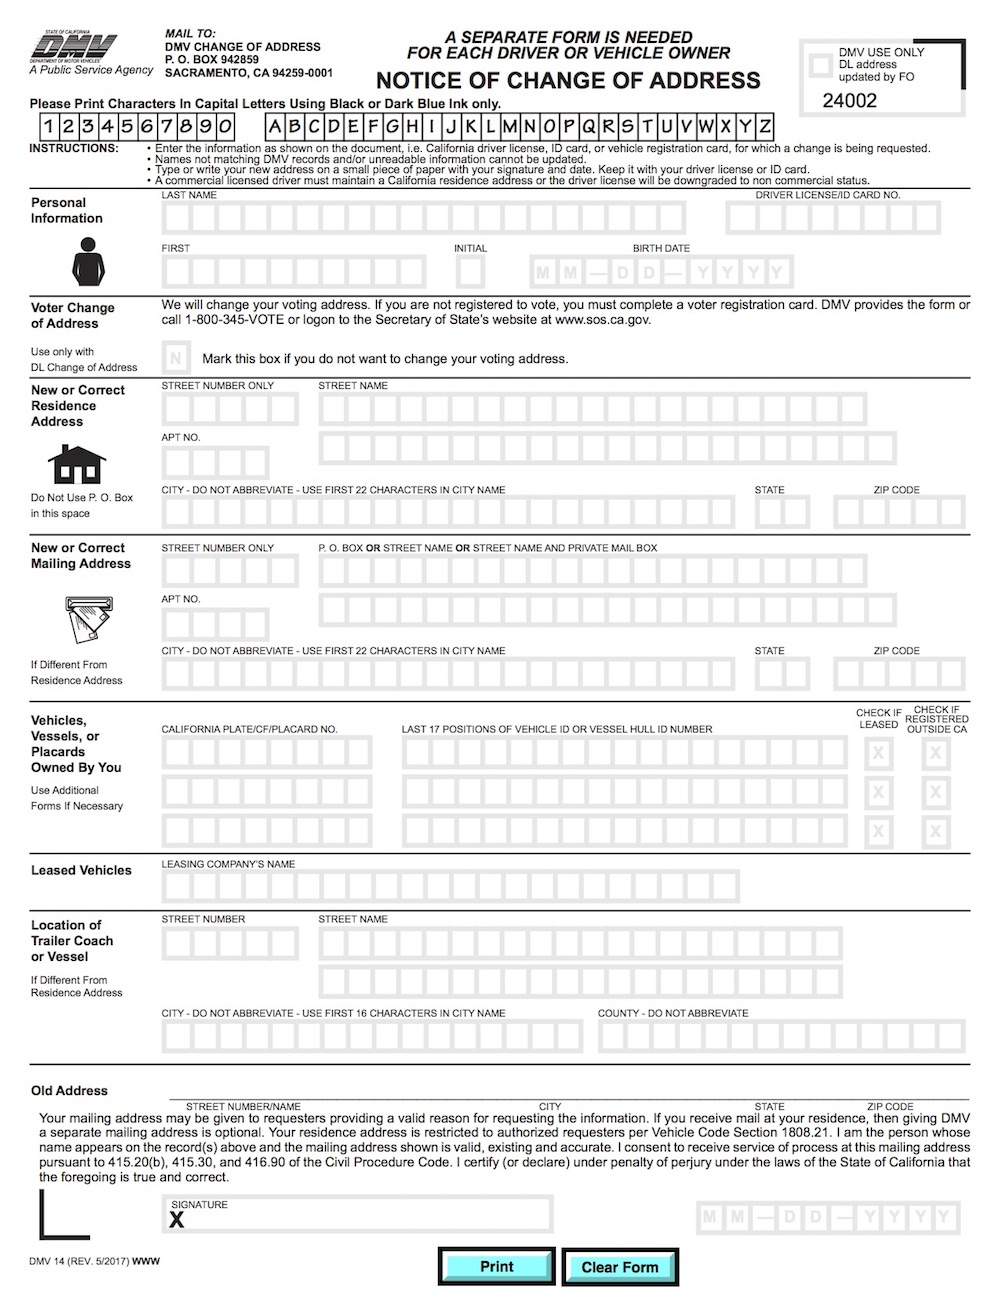

In [222]:
Image(filename="form.jpg")

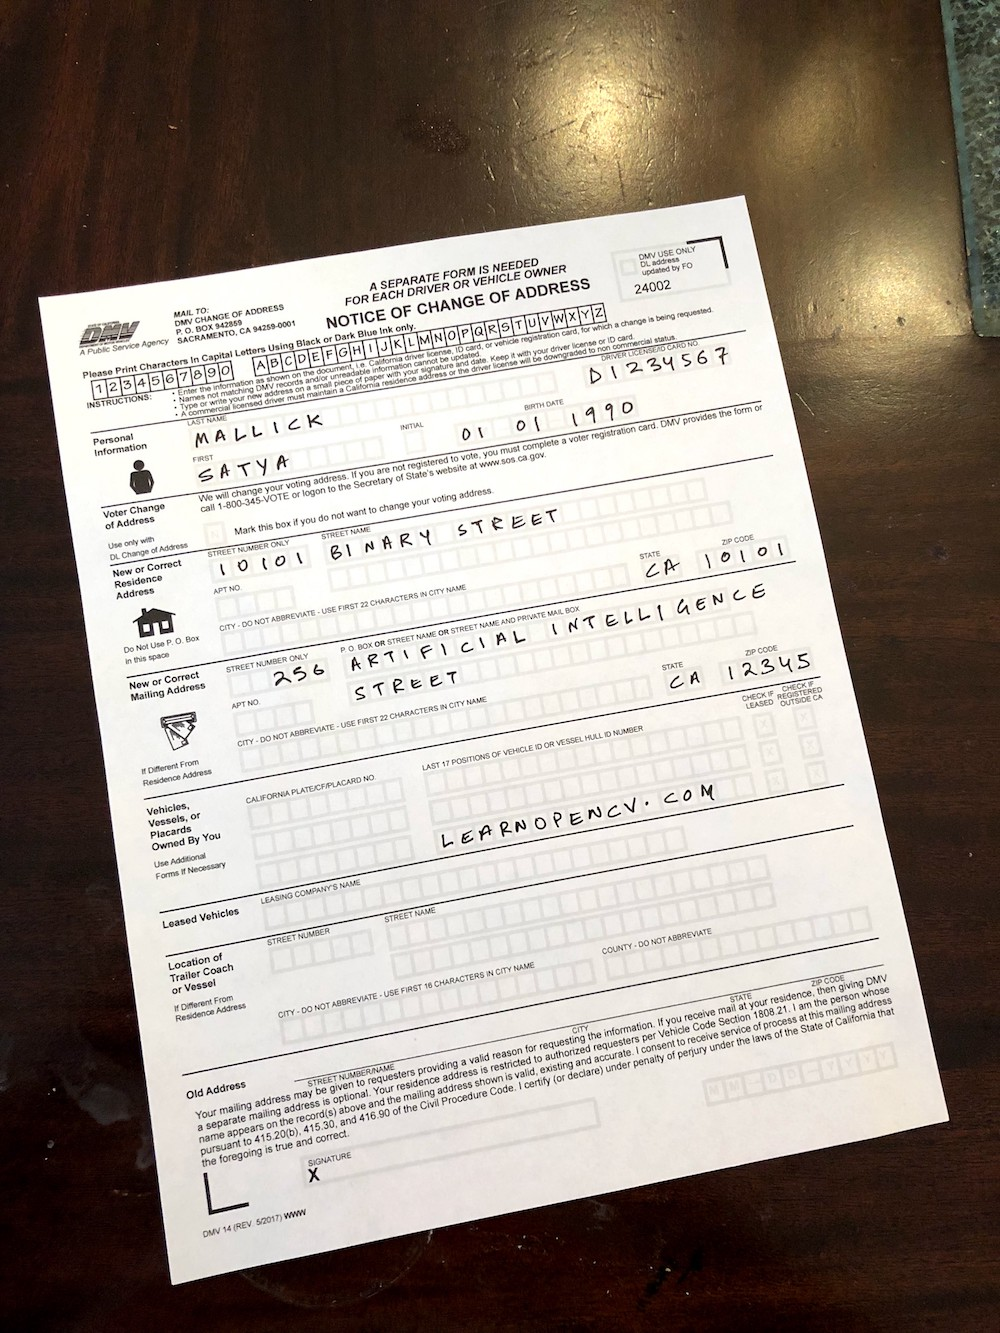

In [224]:
Image(filename="scanned-form.jpg")

### Find some keypoints

ORB is faster than SIFT and SURF

In [314]:
img1_gray = cv2.cvtColor(form, cv2.COLOR_BGR2GRAY)
img2_gray = cv2.cvtColor(scanned_form, cv2.COLOR_BGR2GRAY)

max_features = 500

orb = cv2.ORB_create(max_features)
keypoints1, descriptors1 = orb.detectAndCompute(img1_gray, None)
keypoints2, descriptors2 = orb.detectAndCompute(img2_gray, None)

im1_display = cv2.drawKeypoints(img1_gray, keypoints1, outImage=np.array([]), color=(255, 0, 0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
im2_display = cv2.drawKeypoints(img2_gray, keypoints2, outImage=np.array([]), color=(255, 0, 0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

* Keypoints:
  * Usually intersting features of image, usually associated with edge or corner
  * They are pixel coordinates, which describe the location, scale and orientation of the keypoint
* Descriptors:
  * Vector of some information that describes the region around the keypoint
  * acts as a signature for the keypoint
 
The desciptor is used to search for the same keypoint in two images. (match the keypoints)

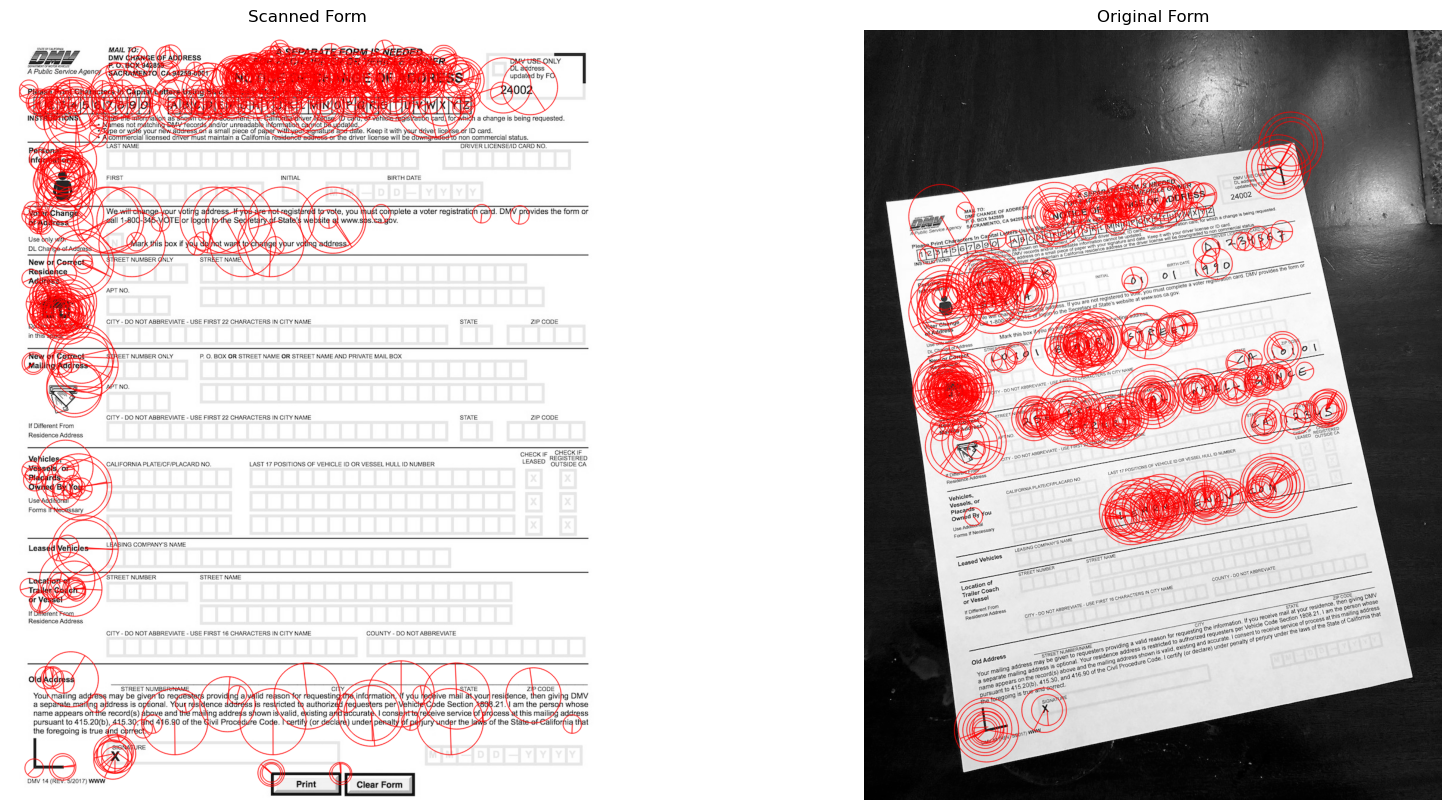

In [316]:
plt.figure(figsize=[20,10])
plt.subplot(121); plt.axis('off'); plt.imshow(im1_display); plt.title("Scanned Form");
plt.subplot(122); plt.axis('off'); plt.imshow(im2_display); plt.title("Original Form");

* The center of the circle is location of keypoint
* The size of cirle is scale of keypoint
* The radius line is orientation of the keypoint

### Match keypoints

In [318]:
matcher = cv2.DescriptorMatcher_create(cv2.DESCRIPTOR_MATCHER_BRUTEFORCE_HAMMING)
matches = list(matcher.match(descriptors1, descriptors2, None))

matches.sort(key=lambda x: x.distance, reverse=False)

# selecting the top matches
num_good_matches = int(len(matches)*0.1)
matches = matches[:num_good_matches]

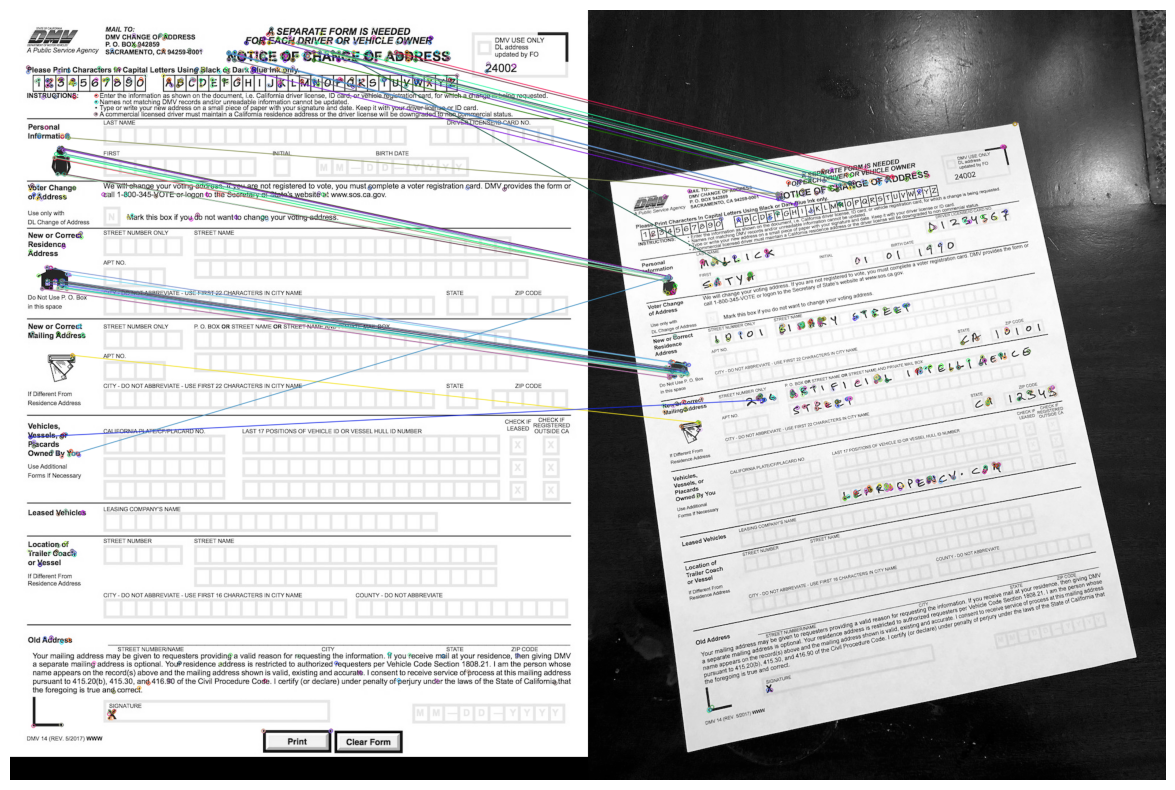

In [320]:
im_matches = cv2.drawMatches(img1_gray, keypoints1, img2_gray, keypoints2, matches, None)
plt.figure(figsize=[40,10])
plt.imshow(im_matches);
plt.axis("off");


In [332]:
points1 = np.zeros((len(matches), 2), dtype=np.float32)
points2 = np.zeros((len(matches), 2), dtype=np.float32)

for i, match in enumerate(matches):
    points1[i, :] = keypoints1[match.queryIdx].pt
    points2[i, :] = keypoints2[match.trainIdx].pt

homography, mask = cv2.findHomography(points2, points1, cv2.RANSAC)

Text(0.5, 1.0, 'Scanned Form')

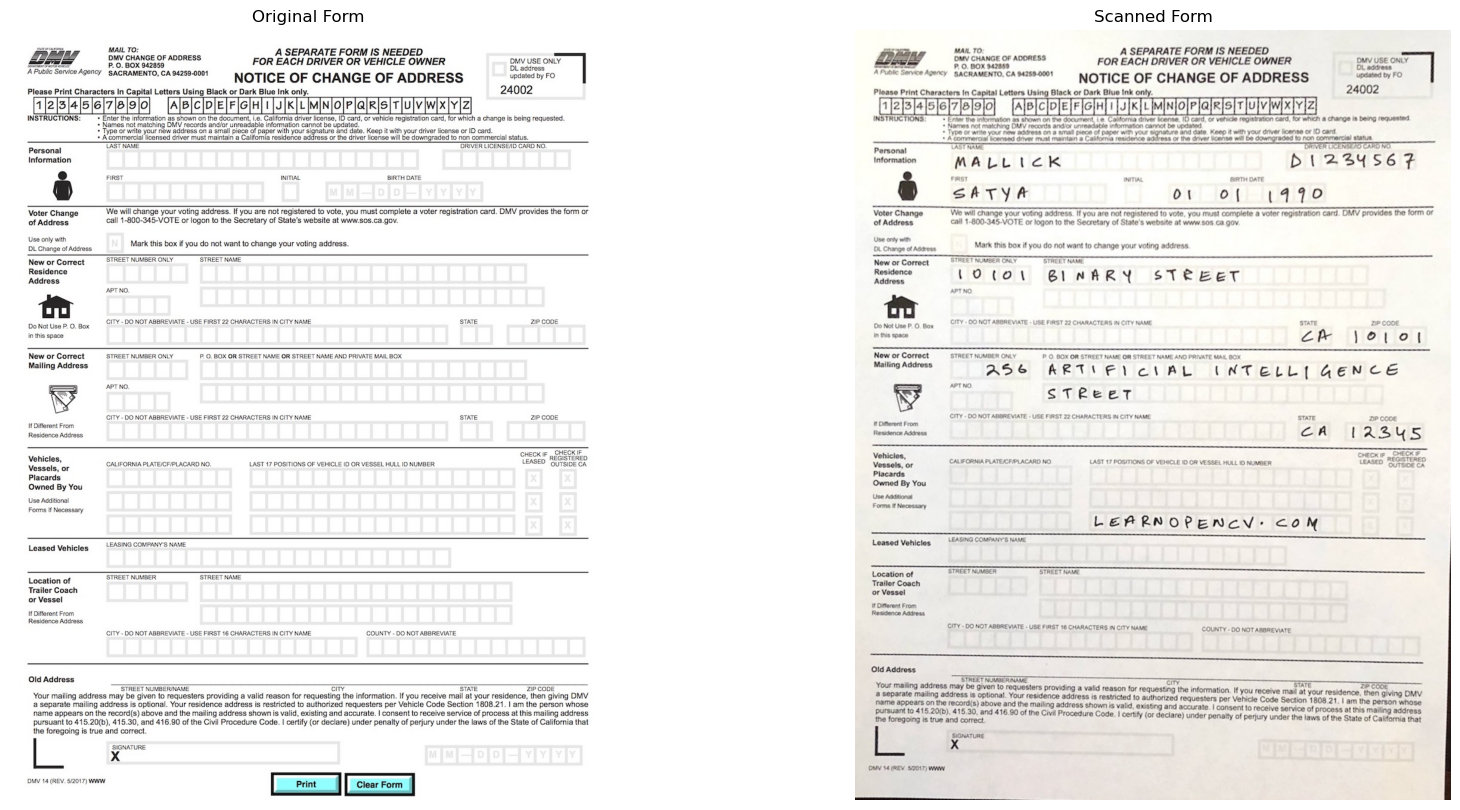

In [334]:
h, w, channels = form.shape
im2_reg = cv2.warpPerspective(scanned_form, homography, (w,h))

plt.figure(figsize=[20, 10])
plt.subplot(121);plt.imshow(form);    plt.axis("off");plt.title("Original Form")
plt.subplot(122);plt.imshow(im2_reg);plt.axis("off");plt.title("Scanned Form")